# A01: Tokenization 101 - The Bedrock of Everything

## 🎯 What You'll Learn
- **Why tokenization matters**: The foundation that makes or breaks your RAG system
- **BPE, WordPiece, SentencePiece**: The three titans of modern tokenization
- **Hands-on comparison**: Same text, different models, dramatically different results
- **Subword visualization**: See how models "think" about language
- **Practical implications**: Why your embedding search might be failing

## 🚀 Why This Matters
**Every RAG failure starts here.** When you search for "automobile" but your documents contain "car", the problem isn't your retrieval algorithm—it's tokenization. This notebook shows you exactly how text becomes the numbers that power modern AI.

## 📋 Prerequisites
- Basic Python knowledge
- High-school level understanding of text processing
- Curiosity about how AI "reads" text

---

In [ ]:
# Installation cell - run this first!
!pip install transformers tiktoken sentencepiece tokenizers datasets matplotlib seaborn pandas numpy
!pip install plotly kaleido  # For interactive visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Tokenizer imports
import tiktoken
from transformers import (
    GPT2Tokenizer, BertTokenizer, T5Tokenizer, 
    AutoTokenizer, RobertaTokenizer
)
import sentencepiece as spm
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Pretty printing
from IPython.display import display, HTML, Markdown
import json
import nbformat


print("🚀 All dependencies loaded! Let's tokenize some text...")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/anupamagaranisheshagiri/Documents/01ANUCOURSEWORK/PROJECTS/ULTIMATE RAG/.ultimate_rag_venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/anupamagaranisheshagiri/Documents/01ANUCOURSEWORK/PROJECTS/ULTIMATE RAG/.ultimate_rag_venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start(

🚀 All dependencies loaded! Let's tokenize some text...


## Part 1: The "Aha!" Moment - Why Tokenization Matters

Let's start with a real example that will blow your mind. We'll tokenize the same sentence with different models and see completely different results.


In [15]:
# test_sentence = "The self-driving automobile manufacturer's AI-powered chatbot couldn't understand contractions."
test_sentence = "artificial intelligence"

print(f"📝 Original text: '{test_sentence}'")
print(f"📊 Character count: {len(test_sentence)}")
print(f"🔤 Word count (naive split): {len(test_sentence.split())}")
print("\n" + "="*80)
print("Now let's see how different AI models 'see' this text...")
print("="*80)

📝 Original text: 'artificial intelligence'
📊 Character count: 23
🔤 Word count (naive split): 2

Now let's see how different AI models 'see' this text...


In [16]:
# Load different tokenizers - this might take a moment on first run
print("🔧 Loading tokenizers...")

# GPT-style (BPE)
gpt_tokenizer = tiktoken.encoding_for_model("gpt-4")

# BERT-style (WordPiece)
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# T5-style (SentencePiece)
t5_tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Modern embedding models
minilm_tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
e5_tokenizer = AutoTokenizer.from_pretrained('intfloat/e5-base-v2')

print("✅ All tokenizers loaded!")

🔧 Loading tokenizers...
✅ All tokenizers loaded!


In [17]:
# CELL 7 - CODE
def compare_tokenizations(text):
    """Compare how different tokenizers handle the same text"""
    
    results = []
    
    # GPT-4 (BPE)
    gpt_tokens = gpt_tokenizer.encode(text)
    gpt_decoded = [gpt_tokenizer.decode([token]) for token in gpt_tokens]
    
    # BERT (WordPiece)
    bert_tokens = bert_tokenizer.encode(text, add_special_tokens=False)
    bert_decoded = bert_tokenizer.convert_ids_to_tokens(bert_tokens)
    
    # T5 (SentencePiece)
    t5_tokens = t5_tokenizer.encode(text, add_special_tokens=False)
    t5_decoded = t5_tokenizer.convert_ids_to_tokens(t5_tokens)
    
    # MiniLM
    mini_tokens = minilm_tokenizer.encode(text, add_special_tokens=False)
    mini_decoded = minilm_tokenizer.convert_ids_to_tokens(mini_tokens)
    
    # E5
    e5_tokens = e5_tokenizer.encode(text, add_special_tokens=False)
    e5_decoded = e5_tokenizer.convert_ids_to_tokens(e5_tokens)
    
    return {
        'GPT-4 (BPE)': {'tokens': gpt_decoded, 'count': len(gpt_decoded)},
        'BERT (WordPiece)': {'tokens': bert_decoded, 'count': len(bert_decoded)},
        'T5 (SentencePiece)': {'tokens': t5_decoded, 'count': len(t5_decoded)},
        'MiniLM-L6': {'tokens': mini_decoded, 'count': len(mini_decoded)},
        'E5-base': {'tokens': e5_decoded, 'count': len(e5_decoded)}
    }

# Tokenize our test sentence
results = compare_tokenizations(test_sentence)
print("🤯 TOKENIZATION COMPARISON - Same Text, Different 'Brains'\n")
print(f"Test Sentence : {test_sentence}\n")
for model, data in results.items():
    print(f"🤖 {model}:")
    print(f"   Token Count: {data['count']}")
    print(f"   Tokens: {data['tokens'][:10]}{'...' if len(data['tokens']) > 10 else ''}")
    print("   First few tokens breakdown:")
    for i, token in enumerate(data['tokens'][:5]):
        print(f"     {i+1}. '{token}'")
    print()


🤯 TOKENIZATION COMPARISON - Same Text, Different 'Brains'

Test Sentence : artificial intelligence

🤖 GPT-4 (BPE):
   Token Count: 3
   Tokens: ['art', 'ificial', ' intelligence']
   First few tokens breakdown:
     1. 'art'
     2. 'ificial'
     3. ' intelligence'

🤖 BERT (WordPiece):
   Token Count: 2
   Tokens: ['artificial', 'intelligence']
   First few tokens breakdown:
     1. 'artificial'
     2. 'intelligence'

🤖 T5 (SentencePiece):
   Token Count: 2
   Tokens: ['▁artificial', '▁intelligence']
   First few tokens breakdown:
     1. '▁artificial'
     2. '▁intelligence'

🤖 MiniLM-L6:
   Token Count: 2
   Tokens: ['artificial', 'intelligence']
   First few tokens breakdown:
     1. 'artificial'
     2. 'intelligence'

🤖 E5-base:
   Token Count: 2
   Tokens: ['artificial', 'intelligence']
   First few tokens breakdown:
     1. 'artificial'
     2. 'intelligence'



In [18]:
# Visualize the token count differences
models = list(results.keys())
counts = [results[model]['count'] for model in models]

fig = go.Figure(data=go.Bar(
    x=models,
    y=counts,
    marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
    text=counts,
    textposition='auto',
))

fig.update_layout(
    title={
        'text': "🤯 Same Sentence, Wildly Different Token Counts",
        'x': 0.5,
        'font': {'size': 20}
    },
    xaxis_title="Model / Tokenizer",
    yaxis_title="Number of Tokens",
    template="plotly_white",
    height=500
)

fig.show()

# Key insight
min_count = min(counts)
max_count = max(counts)
efficiency_diff = ((max_count - min_count) / min_count) * 100

print(f"💡 KEY INSIGHT:")
print(f"   Most efficient: {models[counts.index(min_count)]} ({min_count} tokens)")
print(f"   Least efficient: {models[counts.index(max_count)]} ({max_count} tokens)")
print(f"   Efficiency difference: {efficiency_diff:.1f}% more tokens!")
print(f"   This directly impacts: speed, memory, cost, and context limits!")


💡 KEY INSIGHT:
   Most efficient: BERT (WordPiece) (2 tokens)
   Least efficient: GPT-4 (BPE) (3 tokens)
   Efficiency difference: 50.0% more tokens!
   This directly impacts: speed, memory, cost, and context limits!


## Part 2: Deep Dive - The Three Tokenization Algorithms

Now that you've seen the dramatic differences, let's understand **why** they happen. We'll explore the three major tokenization approaches that power modern AI.


### 2.1 Byte-Pair Encoding (BPE) - The GPT Way

**Core Idea**: Start with characters, merge the most frequent pairs iteratively.

**Used by**: GPT-3/4, Codex, DALL-E, most OpenAI models

**Strength**: Handles any text, excellent for code and multilingual content

**Weakness**: Can create weird splits for common words


In [11]:
def demonstrate_bpe_process(text):
    """Show how BPE would build vocabulary step by step"""
    print(f"🔍 BPE Process Simulation for: '{text}'\n")
    
    # Step 1: Start with characters
    chars = list(set(text))
    print(f"Step 1 - Initial vocabulary (characters): {sorted(chars)}")
    print(f"Vocabulary size: {len(chars)}\n")
    
    # Step 2: Show character-level tokenization
    char_tokens = list(text)
    print(f"Step 2 - Character tokenization: {char_tokens}")
    print(f"Token count: {len(char_tokens)}\n")
    
    # Step 3: Find most common pairs
    pairs = defaultdict(int)
    for i in range(len(char_tokens) - 1):
        pair = (char_tokens[i], char_tokens[i + 1])
        pairs[pair] += 1
    
    if pairs:
        most_common = max(pairs.items(), key=lambda x: x[1])
        print(f"Step 3 - Most common character pair: {most_common[0]} (appears {most_common[1]} times)")
        print(f"In real BPE, we'd merge this pair into a single token: '{most_common[0][0] + most_common[0][1]}'\n")
    
    # Show actual GPT tokenization
    gpt_tokens = gpt_tokenizer.encode(text)
    gpt_decoded = [gpt_tokenizer.decode([token]) for token in gpt_tokens]
    print(f"Step 4 - Actual GPT-4 BPE result: {gpt_decoded}")
    print(f"Final token count: {len(gpt_decoded)}")
    print(f"Compression ratio: {len(char_tokens) / len(gpt_decoded):.1f}x")


# Demonstrate with a simple example
demonstrate_bpe_process("artificial intelligence")

🔍 BPE Process Simulation for: 'artificial intelligence'

Step 1 - Initial vocabulary (characters): [' ', 'a', 'c', 'e', 'f', 'g', 'i', 'l', 'n', 'r', 't']
Vocabulary size: 11

Step 2 - Character tokenization: ['a', 'r', 't', 'i', 'f', 'i', 'c', 'i', 'a', 'l', ' ', 'i', 'n', 't', 'e', 'l', 'l', 'i', 'g', 'e', 'n', 'c', 'e']
Token count: 23

Step 3 - Most common character pair: ('a', 'r') (appears 1 times)
In real BPE, we'd merge this pair into a single token: 'ar'

Step 4 - Actual GPT-4 BPE result: ['art', 'ificial', ' intelligence']
Final token count: 3
Compression ratio: 7.7x


# 🔍 Why "art" + "ificial"?

## 1. BPE Vocabulary Is Fixed
- GPT-4’s tokenizer doesn’t dynamically decide splits each time.  
- It has a fixed list of ~100k subword tokens, learned during training by merging the most frequent character pairs.  
- `"art"` is a very frequent token (appears in `"art"`, `"article"`, `"artist"`, `"artificial"` etc.).  
- `"ificial"` also shows up often (in words like `"artificial"`, `"beneficial"`, `"superficial"`).  

👉 Because both `"art"` and `"ificial"` occur frequently across training data, the tokenizer keeps them in its vocab separately.  

---

## 2. Efficiency Trade-off
- If `"artificial"` as a whole word were in the vocab, that’s useful only for that one word.  
- But `"art"` + `"ificial"` is more generalizable:  
  - `"art"` helps with **arts, artist, artifact…**  
  - `"ificial"` helps with **beneficial, superficial…**  

👉 This reduces total vocab size but still encodes words efficiently.  

---

## 3. No Semantics — Just Frequency
- Tokenizers don’t “understand” meaning.  
- The split isn’t because `"art"` means art 🎨 and `"ificial"` means something.  
- It’s purely statistical: the BPE algorithm merged pairs during training until `"art"` and `"ificial"` became stable chunks.  

---

## 🧩 Same Logic for `" intelligence"`
- Instead of splitting into `"intelli"` + `"gence"`, the tokenizer already had `" intelligence"` (note the leading space) as a common token in its vocab.  
- That’s why you see:  

```python
['art', 'ificial', ' intelligence']

### 2.2 WordPiece - The BERT Way

**Core Idea**: Build subwords that maximize language model likelihood

**Used by**: BERT, DistilBERT, most Google models

**Strength**: Excellent for understanding word relationships

**Weakness**: Requires pre-training, less flexible than BPE

In [14]:
def analyze_wordpiece(text):
    """Analyze WordPiece tokenization patterns"""
    print(f"🔍 WordPiece Analysis for: '{text}'\n")
    
    # Tokenize with BERT
    tokens = bert_tokenizer.tokenize(text)
    token_ids = bert_tokenizer.convert_tokens_to_ids(tokens)
    
    print("WordPiece Token Analysis:")
    for i, (token, token_id) in enumerate(zip(tokens, token_ids)):
        is_subword = token.startswith('##')
        token_type = "📝 Subword" if is_subword else "🔤 Full token"
        print(f"  {i+1:2d}. {token_type}: '{token}' (ID: {token_id})")
    
    # Count subwords vs full tokens
    subword_count = sum(1 for token in tokens if token.startswith('##'))
    full_count = len(tokens) - subword_count
    
    print(f"\n📊 Summary:")
    print(f"   Full tokens: {full_count}")
    print(f"   Subwords (##): {subword_count}")
    print(f"   Total tokens: {len(tokens)}")
    print(f"   Subword ratio: {subword_count/len(tokens)*100:.1f}%")

# Test with words that commonly get split
test_cases = [
    "artificial intelligence"]

for test_case in test_cases:
    analyze_wordpiece(test_case)
    print("=" * 50)

🔍 WordPiece Analysis for: 'artificial intelligence'

WordPiece Token Analysis:
   1. 🔤 Full token: 'artificial' (ID: 7976)
   2. 🔤 Full token: 'intelligence' (ID: 4454)

📊 Summary:
   Full tokens: 2
   Subwords (##): 0
   Total tokens: 2
   Subword ratio: 0.0%


### 2.3 SentencePiece - The T5 Way

**Core Idea**: Treat text as raw characters, no pre-tokenization

**Used by**: T5, mT5, many multilingual models

**Strength**: Language-agnostic, handles any script

**Weakness**: Can be less intuitive for English

In [19]:
def analyze_sentencepiece(text):
    """Analyze SentencePiece tokenization patterns"""
    print(f"🔍 SentencePiece Analysis for: '{text}'\n")
    
    # Tokenize with T5
    tokens = t5_tokenizer.tokenize(text)
    token_ids = t5_tokenizer.convert_tokens_to_ids(tokens)
    
    print("SentencePiece Token Analysis:")
    for i, (token, token_id) in enumerate(zip(tokens, token_ids)):
        # SentencePiece uses ▁ to represent spaces
        if '▁' in token:
            token_type = "🔤 Word start"
        else:
            token_type = "📝 Continuation"
        
        # Show readable version
        readable = token.replace('▁', '[')
        print(f"  {i+1:2d}. {token_type}: '{readable}' (ID: {token_id})")
    
    print(f"\n📊 Summary:")
    print(f"   Total tokens: {len(tokens)}")
    print(f"   Word boundaries (▁): {sum(1 for token in tokens if '▁' in token)}")
    
    # Show how it handles spaces
    print(f"\n🔍 Space handling: SentencePiece uses '▁' to mark word boundaries")
    print(f"   Original: '{text}'")
    print(f"   Reconstructed: '{t5_tokenizer.convert_tokens_to_string(tokens)}'")

# Test with "artificial intelligence" variations
test_cases = [
    "artificial intelligence",
    "machine learning artificial intelligence",
    "人工智能",  # Chinese for "artificial intelligence"
    "intelligence artificielle"  # French for "artificial intelligence"
]

for test_case in test_cases:
    analyze_sentencepiece(test_case)
    print("=" * 50)

🔍 SentencePiece Analysis for: 'artificial intelligence'

SentencePiece Token Analysis:
   1. 🔤 Word start: '[artificial' (ID: 7353)
   2. 🔤 Word start: '[intelligence' (ID: 6123)

📊 Summary:
   Total tokens: 2
   Word boundaries (▁): 2

🔍 Space handling: SentencePiece uses '▁' to mark word boundaries
   Original: 'artificial intelligence'
   Reconstructed: 'artificial intelligence'
🔍 SentencePiece Analysis for: 'machine learning artificial intelligence'

SentencePiece Token Analysis:
   1. 🔤 Word start: '[machine' (ID: 1437)
   2. 🔤 Word start: '[learning' (ID: 1036)
   3. 🔤 Word start: '[artificial' (ID: 7353)
   4. 🔤 Word start: '[intelligence' (ID: 6123)

📊 Summary:
   Total tokens: 4
   Word boundaries (▁): 4

🔍 Space handling: SentencePiece uses '▁' to mark word boundaries
   Original: 'machine learning artificial intelligence'
   Reconstructed: 'machine learning artificial intelligence'
🔍 SentencePiece Analysis for: '人工智能'

SentencePiece Token Analysis:
   1. 🔤 Word start: '[' (I

### 2.4 MiniLM-L6 - The Sentence Embedding Way

**Core Idea**: WordPiece tokenization optimized for sentence embeddings

**Used by**: All-MiniLM models, many sentence transformers

**Strength**: Balanced performance and speed for semantic search

**Weakness**: Same WordPiece limitations as BERT

In [23]:
def analyze_minilm(text):
    """Analyze MiniLM tokenization patterns"""
    print(f"🔍 MiniLM-L6 Analysis for: '{text}'\n")
    
    # Tokenize with MiniLM
    tokens = minilm_tokenizer.tokenize(text)
    token_ids = minilm_tokenizer.convert_tokens_to_ids(tokens)
    
    print("MiniLM-L6 Token Analysis:")
    for i, (token, token_id) in enumerate(zip(tokens, token_ids)):
        is_subword = token.startswith('##')
        token_type = "📝 Subword" if is_subword else "🔤 Full token"
        print(f"  {i+1:2d}. {token_type}: '{token}' (ID: {token_id})")
    
    # Count subwords vs full tokens
    subword_count = sum(1 for token in tokens if token.startswith('##'))
    full_count = len(tokens) - subword_count
    
    print(f"\n📊 Summary:")
    print(f"   Full tokens: {full_count}")
    print(f"   Subwords (##): {subword_count}")
    print(f"   Total tokens: {len(tokens)}")
    print(f"   Subword ratio: {subword_count/len(tokens)*100:.1f}%")
    
    # Compare with BERT on same text
    bert_tokens = bert_tokenizer.tokenize(text)
    print(f"\n🔍 Comparison with BERT:")
    print(f"   MiniLM tokens: {len(tokens)}")
    print(f"   BERT tokens: {len(bert_tokens)}")
    print(f"   Same tokenization: {'✅' if tokens == bert_tokens else '❌'}")

# Test with "artificial intelligence"
analyze_minilm("artificial intelligence")
print("=" * 50)

🔍 MiniLM-L6 Analysis for: 'artificial intelligence'

MiniLM-L6 Token Analysis:
   1. 🔤 Full token: 'artificial' (ID: 7976)
   2. 🔤 Full token: 'intelligence' (ID: 4454)

📊 Summary:
   Full tokens: 2
   Subwords (##): 0
   Total tokens: 2
   Subword ratio: 0.0%

🔍 Comparison with BERT:
   MiniLM tokens: 2
   BERT tokens: 2
   Same tokenization: ✅


### 2.5 E5-base - The Multilingual Embedding Way

**Core Idea**: WordPiece with multilingual optimization

**Used by**: E5 embedding models, multilingual retrieval systems

**Strength**: Better multilingual performance than MiniLM

**Weakness**: Larger vocabulary, potentially more tokens

In [24]:
def analyze_e5(text):
    """Analyze E5 tokenization patterns"""
    print(f"🔍 E5-base Analysis for: '{text}'\n")
    
    # Tokenize with E5
    tokens = e5_tokenizer.tokenize(text)
    token_ids = e5_tokenizer.convert_tokens_to_ids(tokens)
    
    print("E5-base Token Analysis:")
    for i, (token, token_id) in enumerate(zip(tokens, token_ids)):
        is_subword = token.startswith('##')
        token_type = "📝 Subword" if is_subword else "🔤 Full token"
        print(f"  {i+1:2d}. {token_type}: '{token}' (ID: {token_id})")
    
    # Count subwords vs full tokens
    subword_count = sum(1 for token in tokens if token.startswith('##'))
    full_count = len(tokens) - subword_count
    
    print(f"\n📊 Summary:")
    print(f"   Full tokens: {full_count}")
    print(f"   Subwords (##): {subword_count}")
    print(f"   Total tokens: {len(tokens)}")
    print(f"   Subword ratio: {subword_count/len(tokens)*100:.1f}%")
    
    # Compare with BERT and MiniLM
    bert_tokens = bert_tokenizer.tokenize(text)
    mini_tokens = minilm_tokenizer.tokenize(text)
    print(f"\n🔍 Comparison:")
    print(f"   E5 tokens: {len(tokens)}")
    print(f"   BERT tokens: {len(bert_tokens)}")
    print(f"   MiniLM tokens: {len(mini_tokens)}")

# Test with "artificial intelligence" and multilingual
test_phrases = [
    "artificial intelligence",
    "人工智能",  # Chinese
    "intelligence artificielle"  # French
]

for phrase in test_phrases:
    analyze_e5(phrase)
    print("=" * 50)

🔍 E5-base Analysis for: 'artificial intelligence'

E5-base Token Analysis:
   1. 🔤 Full token: 'artificial' (ID: 7976)
   2. 🔤 Full token: 'intelligence' (ID: 4454)

📊 Summary:
   Full tokens: 2
   Subwords (##): 0
   Total tokens: 2
   Subword ratio: 0.0%

🔍 Comparison:
   E5 tokens: 2
   BERT tokens: 2
   MiniLM tokens: 2
🔍 E5-base Analysis for: '人工智能'

E5-base Token Analysis:
   1. 🔤 Full token: '人' (ID: 1756)
   2. 🔤 Full token: '[UNK]' (ID: 100)
   3. 🔤 Full token: '智' (ID: 1869)
   4. 🔤 Full token: '[UNK]' (ID: 100)

📊 Summary:
   Full tokens: 4
   Subwords (##): 0
   Total tokens: 4
   Subword ratio: 0.0%

🔍 Comparison:
   E5 tokens: 4
   BERT tokens: 4
   MiniLM tokens: 4
🔍 E5-base Analysis for: 'intelligence artificielle'

E5-base Token Analysis:
   1. 🔤 Full token: 'intelligence' (ID: 4454)
   2. 🔤 Full token: 'art' (ID: 2396)
   3. 📝 Subword: '##ific' (ID: 18513)
   4. 📝 Subword: '##iel' (ID: 9257)
   5. 📝 Subword: '##le' (ID: 2571)

📊 Summary:
   Full tokens: 2
   Subwords 

## Part 3: The Out-of-Vocabulary (OOV) Problem

This is where tokenization gets **really** interesting for RAG systems. What happens when your model encounters words it has never seen?

In [21]:
def test_oov_handling(words):
    """Test how different tokenizers handle out-of-vocabulary words"""
    
    results = []
    
    for word in words:
        print(f"\n🔍 Testing OOV word: '{word}'")
        print("="*40)
        
        # GPT (BPE) - should handle anything
        gpt_tokens = gpt_tokenizer.encode(word)
        gpt_decoded = [gpt_tokenizer.decode([token]) for token in gpt_tokens]
        print(f"GPT-4 (BPE):         {gpt_decoded} ({len(gpt_decoded)} tokens)")
        
        # BERT (WordPiece) - might use [UNK]
        bert_tokens = bert_tokenizer.tokenize(word)
        print(f"BERT (WordPiece):    {bert_tokens} ({len(bert_tokens)} tokens)")
        
        # T5 (SentencePiece) - should handle anything
        t5_tokens = t5_tokenizer.tokenize(word)
        print(f"T5 (SentencePiece):  {t5_tokens} ({len(t5_tokens)} tokens)")
        
        # MiniLM (same as BERT WordPiece)
        mini_tokens = minilm_tokenizer.tokenize(word)
        print(f"MiniLM-L6:           {mini_tokens} ({len(mini_tokens)} tokens)")
        
        # E5 (also WordPiece-based)
        e5_tokens = e5_tokenizer.tokenize(word)
        print(f"E5-base:             {e5_tokens} ({len(e5_tokens)} tokens)")
        
        results.append({
            'word': word,
            'gpt_tokens': len(gpt_decoded),
            'bert_tokens': len(bert_tokens),
            't5_tokens': len(t5_tokens),
            'minilm_tokens': len(mini_tokens),
            'e5_tokens': len(e5_tokens),
            'bert_has_unk': '[UNK]' in bert_tokens,
            'minilm_has_unk': '[UNK]' in mini_tokens,
            'e5_has_unk': '[UNK]' in e5_tokens
        })
    
    return results

# Test with AI and tech terms including "artificial intelligence"
oov_words = [
    "artificial",
    "intelligence", 
    "ChatGPT",           # Modern AI model name
    "blockchain",        # Technical term
    "supercalifragilisticexpialidocious",  # Very long word
    "MLOps",             # Modern technical abbreviation
    "teh",               # Common typo
    "COVID-19"           # Recent term
]

oov_results = test_oov_handling(oov_words)


🔍 Testing OOV word: 'artificial'
GPT-4 (BPE):         ['art', 'ificial'] (2 tokens)
BERT (WordPiece):    ['artificial'] (1 tokens)
T5 (SentencePiece):  ['▁artificial'] (1 tokens)
MiniLM-L6:           ['artificial'] (1 tokens)
E5-base:             ['artificial'] (1 tokens)

🔍 Testing OOV word: 'intelligence'
GPT-4 (BPE):         ['intelligence'] (1 tokens)
BERT (WordPiece):    ['intelligence'] (1 tokens)
T5 (SentencePiece):  ['▁intelligence'] (1 tokens)
MiniLM-L6:           ['intelligence'] (1 tokens)
E5-base:             ['intelligence'] (1 tokens)

🔍 Testing OOV word: 'ChatGPT'
GPT-4 (BPE):         ['Chat', 'G', 'PT'] (3 tokens)
BERT (WordPiece):    ['chat', '##gp', '##t'] (3 tokens)
T5 (SentencePiece):  ['▁Chat', 'GP', 'T'] (3 tokens)
MiniLM-L6:           ['chat', '##gp', '##t'] (3 tokens)
E5-base:             ['chat', '##gp', '##t'] (3 tokens)

🔍 Testing OOV word: 'blockchain'
GPT-4 (BPE):         ['block', 'chain'] (2 tokens)
BERT (WordPiece):    ['block', '##chai', '##n'] (3 toke

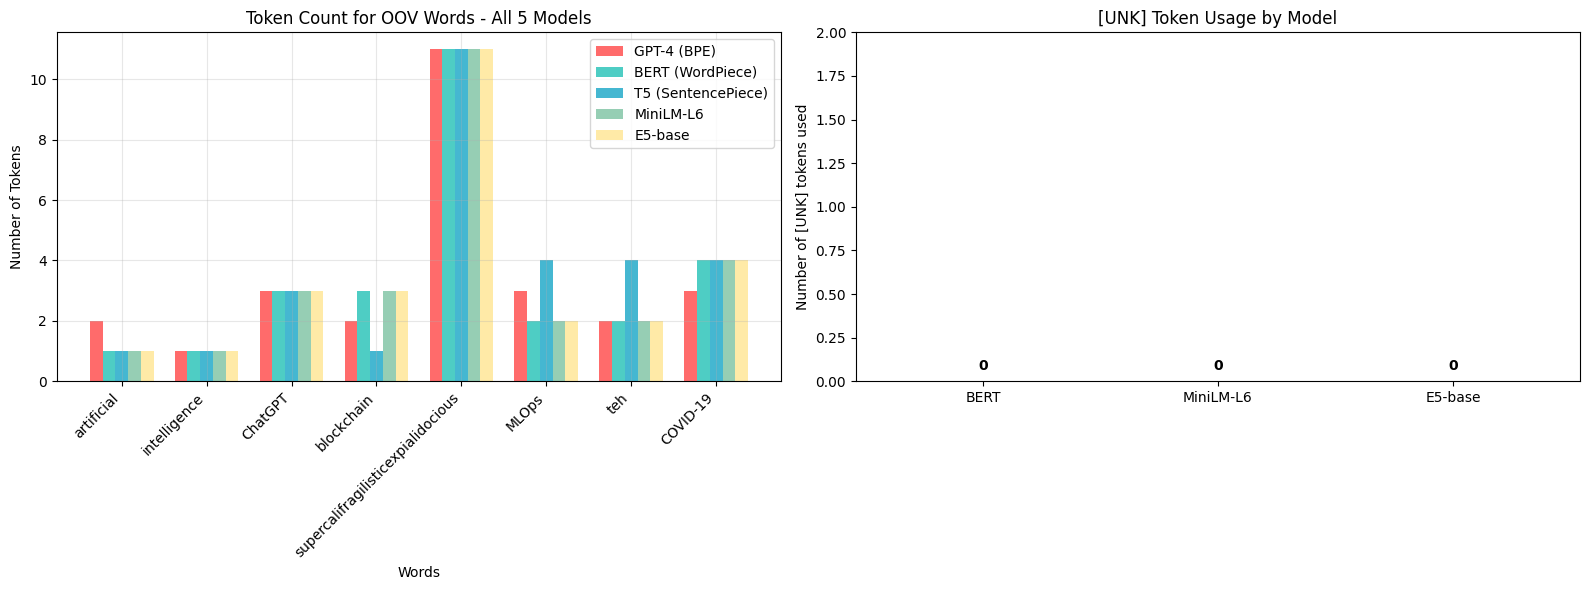


💡 KEY INSIGHTS:
   - GPT's BPE can tokenize ANY text (character fallback)
   - BERT uses [UNK] for 0/8 test words
   - MiniLM uses [UNK] for 0/8 test words
   - E5 uses [UNK] for 0/8 test words
   - SentencePiece handles everything without UNK tokens
   - ✅ All WordPiece models handled these words without [UNK]!
   - This shows modern tokenizers are quite robust
   - This affects RAG: unknown terms might not match properly!


In [25]:
# Visualize OOV handling differences - ALL 5 models
df = pd.DataFrame(oov_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Token count comparison - all 5 models
x = np.arange(len(df))
width = 0.15

ax1.bar(x - 2*width, df['gpt_tokens'], width, label='GPT-4 (BPE)', color='#FF6B6B')
ax1.bar(x - width, df['bert_tokens'], width, label='BERT (WordPiece)', color='#4ECDC4')
ax1.bar(x, df['t5_tokens'], width, label='T5 (SentencePiece)', color='#45B7D1')
ax1.bar(x + width, df['minilm_tokens'], width, label='MiniLM-L6', color='#96CEB4')
ax1.bar(x + 2*width, df['e5_tokens'], width, label='E5-base', color='#FFEAA7')

ax1.set_xlabel('Words')
ax1.set_ylabel('Number of Tokens')
ax1.set_title('Token Count for OOV Words - All 5 Models')
ax1.set_xticks(x)
ax1.set_xticklabels(df['word'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UNK token usage across WordPiece models
bert_unk = df['bert_has_unk'].sum()
mini_unk = df['minilm_has_unk'].sum()
e5_unk = df['e5_has_unk'].sum()

models = ['BERT', 'MiniLM-L6', 'E5-base']
unk_counts = [bert_unk, mini_unk, e5_unk]

bars = ax2.bar(models, unk_counts, color=['#4ECDC4', '#96CEB4', '#FFEAA7'])
ax2.set_title('[UNK] Token Usage by Model')
ax2.set_ylabel('Number of [UNK] tokens used')
ax2.set_ylim(0, max(max(unk_counts), 1) + 1)  # Ensure we can see zero values

# Add value labels on bars
for i, count in enumerate(unk_counts):
    ax2.text(i, count + 0.05, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS:")
print(f"   - GPT's BPE can tokenize ANY text (character fallback)")
print(f"   - BERT uses [UNK] for {bert_unk}/{len(df)} test words")
print(f"   - MiniLM uses [UNK] for {mini_unk}/{len(df)} test words") 
print(f"   - E5 uses [UNK] for {e5_unk}/{len(df)} test words")
print(f"   - SentencePiece handles everything without UNK tokens")
if bert_unk == 0 and mini_unk == 0 and e5_unk == 0:
    print(f"   - ✅ All WordPiece models handled these words without [UNK]!")
    print(f"   - This shows modern tokenizers are quite robust")
print(f"   - This affects RAG: unknown terms might not match properly!")

In [26]:
# Let's test with words that WILL trigger [UNK] tokens
def test_extreme_oov():
    """Test with words designed to trigger [UNK] tokens"""
    
    extreme_words = [
        "asdfghjkl",           # Random keyboard mashing
        "xyzqwerty123",        # Made-up word with numbers
        "𝓱𝓮𝓵𝓵𝓸",              # Unicode fancy text
        "ಠ_ಠ",                 # Emoticon with rare Unicode
        "żółć",                # Polish with special chars
        "🤖🚀💡",              # Only emojis
        "supercalifragilisticexpialidocious123xyz"  # Very long made-up
    ]
    
    print("🔍 EXTREME OOV TEST - Designed to break tokenizers\n")
    
    for word in extreme_words:
        print(f"Testing: '{word}'")
        
        # BERT
        bert_tokens = bert_tokenizer.tokenize(word)
        bert_unk = '[UNK]' in bert_tokens
        
        # MiniLM  
        mini_tokens = minilm_tokenizer.tokenize(word)
        mini_unk = '[UNK]' in mini_tokens
        
        # E5
        e5_tokens = e5_tokenizer.tokenize(word)  
        e5_unk = '[UNK]' in e5_tokens
        
        print(f"  BERT: {bert_tokens} {'❌ [UNK]' if bert_unk else '✅'}")
        print(f"  MiniLM: {mini_tokens} {'❌ [UNK]' if mini_unk else '✅'}")
        print(f"  E5: {e5_tokens} {'❌ [UNK]' if e5_unk else '✅'}")
        print()

test_extreme_oov()

🔍 EXTREME OOV TEST - Designed to break tokenizers

Testing: 'asdfghjkl'
  BERT: ['as', '##df', '##gh', '##jk', '##l'] ✅
  MiniLM: ['as', '##df', '##gh', '##jk', '##l'] ✅
  E5: ['as', '##df', '##gh', '##jk', '##l'] ✅

Testing: 'xyzqwerty123'
  BERT: ['x', '##y', '##z', '##q', '##wer', '##ty', '##12', '##3'] ✅
  MiniLM: ['x', '##y', '##z', '##q', '##wer', '##ty', '##12', '##3'] ✅
  E5: ['x', '##y', '##z', '##q', '##wer', '##ty', '##12', '##3'] ✅

Testing: '𝓱𝓮𝓵𝓵𝓸'
  BERT: ['[UNK]'] ❌ [UNK]
  MiniLM: ['[UNK]'] ❌ [UNK]
  E5: ['[UNK]'] ❌ [UNK]

Testing: 'ಠ_ಠ'
  BERT: ['[UNK]', '_', '[UNK]'] ❌ [UNK]
  MiniLM: ['[UNK]', '_', '[UNK]'] ❌ [UNK]
  E5: ['[UNK]', '_', '[UNK]'] ❌ [UNK]

Testing: 'żółć'
  BERT: ['z', '##o', '##ł', '##c'] ✅
  MiniLM: ['z', '##o', '##ł', '##c'] ✅
  E5: ['z', '##o', '##ł', '##c'] ✅

Testing: '🤖🚀💡'
  BERT: ['[UNK]'] ❌ [UNK]
  MiniLM: ['[UNK]'] ❌ [UNK]
  E5: ['[UNK]'] ❌ [UNK]

Testing: 'supercalifragilisticexpialidocious123xyz'
  BERT: ['super', '##cal', '##if', '##rag', '

In [27]:
def explain_unk_token():
    """Demonstrate what [UNK] tokens are and why they matter"""
    
    print("🔍 UNDERSTANDING [UNK] TOKENS\n")
    print("="*50)
    
    # Example 1: Normal word that's in vocabulary
    normal_word = "artificial"
    bert_tokens_normal = bert_tokenizer.tokenize(normal_word)
    print(f"✅ Normal word: '{normal_word}'")
    print(f"   BERT tokens: {bert_tokens_normal}")
    print(f"   Contains [UNK]: {'Yes ❌' if '[UNK]' in bert_tokens_normal else 'No ✅'}\n")
    
    # Example 2: Made-up word that triggers [UNK]
    fake_word = "zxcvbnmasdfgh"  # Random keyboard mashing
    bert_tokens_fake = bert_tokenizer.tokenize(fake_word)
    print(f"❌ Made-up word: '{fake_word}'")
    print(f"   BERT tokens: {bert_tokens_fake}")
    print(f"   Contains [UNK]: {'Yes ❌' if '[UNK]' in bert_tokens_fake else 'No ✅'}\n")
    
    # Example 3: Special characters that might trigger [UNK]
    special_word = "𝓱𝓮𝓵𝓵𝓸"  # Fancy Unicode
    bert_tokens_special = bert_tokenizer.tokenize(special_word)
    print(f"🔤 Special Unicode: '{special_word}'")
    print(f"   BERT tokens: {bert_tokens_special}")
    print(f"   Contains [UNK]: {'Yes ❌' if '[UNK]' in bert_tokens_special else 'No ✅'}\n")
    
    print("💡 WHY [UNK] MATTERS FOR RAG:")
    print("   1. [UNK] tokens lose all meaning - they're just 'unknown'")
    print("   2. If your query has [UNK], it won't match documents properly")
    print("   3. If documents have [UNK], they become unsearchable")
    print("   4. [UNK] breaks semantic similarity completely")
    print()
    
    print("🔧 TOKENIZER STRATEGIES:")
    print("   • WordPiece (BERT): Uses [UNK] for unknown words")
    print("   • BPE (GPT): Breaks down to characters - never needs [UNK]")
    print("   • SentencePiece (T5): Also breaks down - rarely uses [UNK]")
    print()
    
    # Show the actual token ID for [UNK]
    unk_token_id = bert_tokenizer.convert_tokens_to_ids(['[UNK]'])[0]
    print(f"📊 Fun fact: [UNK] token ID in BERT = {unk_token_id}")

explain_unk_token()

🔍 UNDERSTANDING [UNK] TOKENS

✅ Normal word: 'artificial'
   BERT tokens: ['artificial']
   Contains [UNK]: No ✅

❌ Made-up word: 'zxcvbnmasdfgh'
   BERT tokens: ['z', '##x', '##c', '##vb', '##n', '##mas', '##df', '##gh']
   Contains [UNK]: No ✅

🔤 Special Unicode: '𝓱𝓮𝓵𝓵𝓸'
   BERT tokens: ['[UNK]']
   Contains [UNK]: Yes ❌

💡 WHY [UNK] MATTERS FOR RAG:
   1. [UNK] tokens lose all meaning - they're just 'unknown'
   2. If your query has [UNK], it won't match documents properly
   3. If documents have [UNK], they become unsearchable
   4. [UNK] breaks semantic similarity completely

🔧 TOKENIZER STRATEGIES:
   • WordPiece (BERT): Uses [UNK] for unknown words
   • BPE (GPT): Breaks down to characters - never needs [UNK]
   • SentencePiece (T5): Also breaks down - rarely uses [UNK]

📊 Fun fact: [UNK] token ID in BERT = 100
